[2026-02-05 19:38:21] [info     ] 🚀 Starting Momentum Factor Backtest: 2023-01-01 to 2023-01-01
[2026-02-05 19:38:21] [info     ] Processing Chunk: 2023-01-01 00:00:00 => 2023-01-31 23:59:59
[2026-02-05 19:38:25] [info     ] ✅ Chunk Done. Rows: 76800
[2026-02-05 19:38:25] [info     ] 🧩 Concatenating all chunks...
[2026-02-05 19:38:25] [info     ] 🎉 All Done! Final Shape: (76800, 3)
[2026-02-05 19:38:25] [info     ] Sample:
                     date instrument    factor
8316  2023-01-03 09:45:00  000001.SZ -0.008134
10594 2023-01-03 09:45:00  000002.SZ  0.011619
16337 2023-01-03 09:45:00  000063.SZ  0.052822
10695 2023-01-03 09:45:00  000069.SZ -0.049785
15547 2023-01-03 09:45:00  000100.SZ  0.013118
[2026-02-05 19:38:25] [info     ] 📊 Starting Evaluation...
[2026-02-05 19:38:25] [warning  ] eval_dwc._latest version='v13' (use ._latest for dev only, not for prod)
[2026-02-05 19:38:26] [info     ] eval_dwc.v13 开始运行 ..
[2026-02-05 19:38:26] [info     ] ========== 数据检查 ==========
[2026-02-


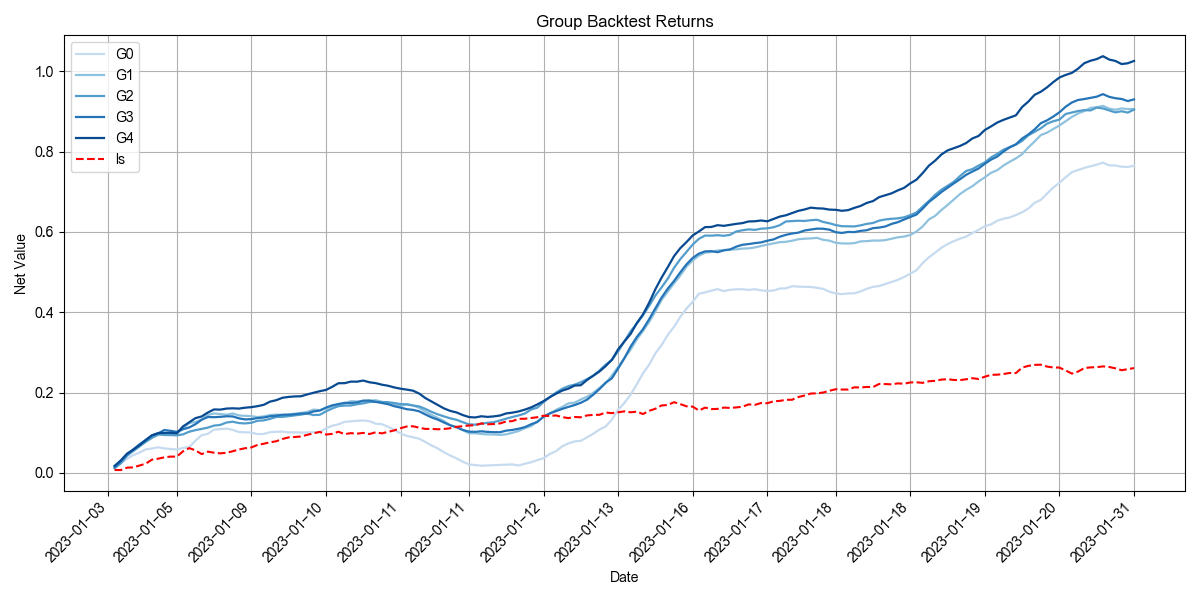
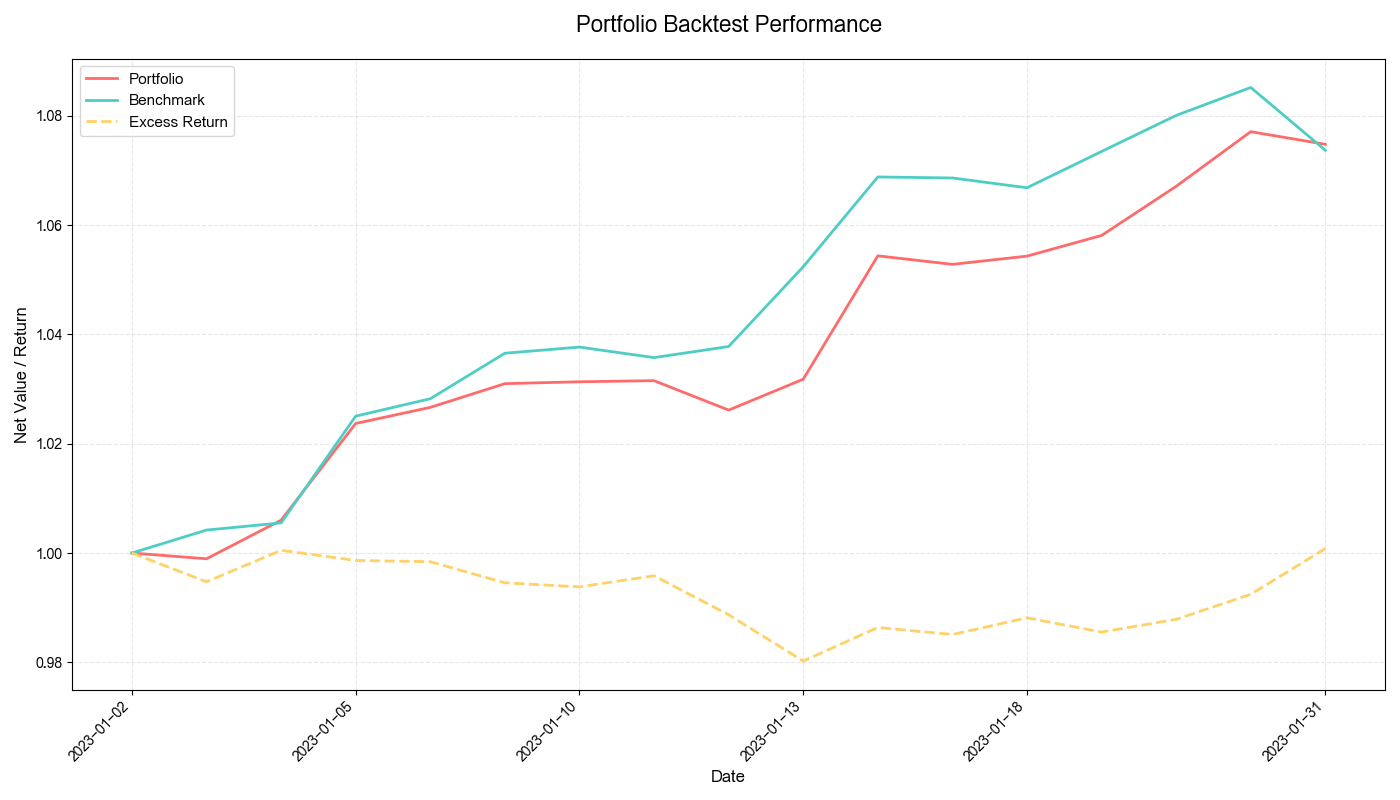

[2026-02-05 19:38:37] [info     ] eval_dwc.v13 运行完成 [11.539s].


In [2]:
def main(datasource, start_date, end_date):
    """
    factor function
    构建 15分钟频率的动量因子 (Intraday Momentum)
    Args:
        datasource (str): Datasource table name
        start_date (str): Start date in 'YYYY-MM-DD HH:MM:SS' format
        end_date (str): End date in 'YYYY-MM-DD HH:MM:SS' format

    Returns:
        pd.DataFrame: Factor data with columns ['date', 'instrument', 'factor']
    """
    import pandas as pd
    import dai

    sql = f"""
    -- 优化设置
    SET preserve_insertion_order=false;
    SET threads=4;

    WITH cte_snapshot AS (
        SELECT
            date, instrument_id,

            -- 使用中间价 (Mid Price) 减少由于买卖档波动造成的噪音
            (ask_price1 + bid_price1) / 2 as mid_price,

            -- 交易日
            strftime(date, '%Y-%m-%d') as trading_day,

            -- 按15分钟分段的时间列
            CASE 
                -- 上午时间段
                WHEN strftime(date, '%H%M') >= '0930' AND strftime(date, '%H%M') < '0945' THEN 94500
                WHEN strftime(date, '%H%M') >= '0945' AND strftime(date, '%H%M') < '1000' THEN 100000
                WHEN strftime(date, '%H%M') >= '1000' AND strftime(date, '%H%M') < '1015' THEN 101500
                WHEN strftime(date, '%H%M') >= '1015' AND strftime(date, '%H%M') < '1030' THEN 103000
                WHEN strftime(date, '%H%M') >= '1030' AND strftime(date, '%H%M') < '1045' THEN 104500
                WHEN strftime(date, '%H%M') >= '1045' AND strftime(date, '%H%M') < '1100' THEN 110000
                WHEN strftime(date, '%H%M') >= '1100' AND strftime(date, '%H%M') < '1115' THEN 111500
                WHEN strftime(date, '%H%M') >= '1115' AND strftime(date, '%H%M') <= '1130' THEN 113000

                -- 下午时间段
                WHEN strftime(date, '%H%M') >= '1300' AND strftime(date, '%H%M') < '1315' THEN 131500
                WHEN strftime(date, '%H%M') >= '1315' AND strftime(date, '%H%M') < '1330' THEN 133000
                WHEN strftime(date, '%H%M') >= '1330' AND strftime(date, '%H%M') < '1345' THEN 134500
                WHEN strftime(date, '%H%M') >= '1345' AND strftime(date, '%H%M') < '1400' THEN 140000
                WHEN strftime(date, '%H%M') >= '1400' AND strftime(date, '%H%M') < '1415' THEN 141500
                WHEN strftime(date, '%H%M') >= '1415' AND strftime(date, '%H%M') < '1430' THEN 143000
                WHEN strftime(date, '%H%M') >= '1430' AND strftime(date, '%H%M') < '1445' THEN 144500
                WHEN strftime(date, '%H%M') >= '1445' AND strftime(date, '%H%M') < '1457' THEN 150000

                ELSE -1
            END as time_segment

        FROM {datasource}
    ),
    cte_filtered AS (
        SELECT *
        FROM cte_snapshot
        WHERE time_segment != -1
    ),
    -- 计算每个15分钟窗口内的动量：close - average
    cte_window AS (
        SELECT
            trading_day, time_segment, instrument_id,

            -- 开盘/收盘中间价（仍保留，便于对比/排查）
            argMin(mid_price, date) as open_mid,
            argMax(mid_price, date) as close_mid,

            -- ✅ 窗口内均值（十五分钟内均值）
            avg(mid_price) as avg_mid,

            -- ✅ 动量计算：(收盘 - 均值) / 均值
            (close_mid - avg_mid) / (avg_mid + 1e-8) as raw_momentum,

            -- 因子处理：动量反转（负号） + tanh 缩放
            -1 * tanh(raw_momentum * 10) as factor

        FROM cte_filtered
        GROUP BY instrument_id, trading_day, time_segment
    )

    SELECT
        CAST(CONCAT(
            f.trading_day,
            ' ',
            strftime(strptime(LPAD(f.time_segment, 6, '0'), '%H%M%S'), '%H:%M:%S')
        ) AS DATETIME) AS date,
        all_instruments.instrument,
        f.factor
    FROM cte_window f
    LEFT JOIN all_instruments USING (instrument_id)
    """

    df = dai.query(sql, filters={'date': [start_date, end_date]}).df()
    return df


if __name__ == '__main__':
    """
    开发调试专用模块：分块循环回测引擎
    (这部分代码保持不变，用于本地分段跑数据验证)
    """
    from bigmodule import M
    from datetime import datetime
    import pandas as pd
    import structlog
    import gc

    logger = structlog.get_logger()
    datasource = 'cpt_dwc_2026_stock_hs300_snapshot'

    # ==========================================
    # 配置回测时间范围
    # ==========================================
    full_start_date = '2023-01-01'
    full_end_date = '2023-01-01'

    date_ranges = pd.date_range(start=full_start_date, end=full_end_date, freq='MS')
    all_results = []

    logger.info(f"🚀 Starting Momentum Factor Backtest: {full_start_date} to {full_end_date}")

    for start_dt in date_ranges:
        current_start = start_dt.strftime('%Y-%m-%d 00:00:00')
        current_end = (start_dt + pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d 23:59:59')

        logger.info(f"Processing Chunk: {current_start} => {current_end}")

        try:
            df_chunk = main(datasource, current_start, current_end)

            if df_chunk is not None and not df_chunk.empty:
                all_results.append(df_chunk)
                logger.info(f"✅ Chunk Done. Rows: {len(df_chunk)}")
            else:
                logger.warning(f"⚠️ Chunk Empty: {current_start}")

            del df_chunk
            gc.collect()

        except Exception as e:
            logger.error(f"❌ Error in chunk {current_start}: {e}")

    if all_results:
        logger.info("🧩 Concatenating all chunks...")
        final_data = pd.concat(all_results, ignore_index=True)
        final_data.sort_values(by=['date', 'instrument'], inplace=True)

        logger.info(f"🎉 All Done! Final Shape: {final_data.shape}")
        logger.info(f"Sample:\n{final_data.head()}")

        logger.info("📊 Starting Evaluation...")
        try:
            results = M.eval_dwc._latest(data=final_data)
        except Exception as e:
            logger.warning(f"Evaluation failed (local environment might miss specific modules): {e}")
            print("Data preview:", final_data.head())
    else:
        logger.error("No data generated.")
